<a href="https://colab.research.google.com/github/ditodewantoro/DATA-ANALYST/blob/main/Pemodelan_Topik_Judul_Berita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SCRAPPING DATA**

In [ ]:
!pip install requests beautifulsoup4 dateparser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 22.3 MB/s eta 0:00:00


In [ ]:
from googlesearch import search
import random
import time
import requests
from bs4 import BeautifulSoup
import os
import csv

os.makedirs("failed_html", exist_ok=True)

query = 'olah raga site:cnnindonesia.com after:2025-03-29 before:2025-06-29'
jumlah_link = 300
hasil_scrape = []

headers = {'User-Agent': 'Mozilla/5.0'}

link_berita = list(search(query, num=10, stop=jumlah_link))

for idx, url in enumerate(link_berita):
    try:
        if any(x in url for x in ['video', 'foto', 'audio', 'podcast', 'embed']):
            print(f"[{idx+1}] Lewat (media player/podcast): {url}")
            continue

        res = requests.get(url, headers=headers)
        if res.status_code != 200:
            print(f"[{idx+1}] ❌ HTTP {res.status_code}: {url}")
            continue

        soup = BeautifulSoup(res.text, 'html.parser')

        title_tag = soup.find('h1') or soup.find('title')
        title = title_tag.text.strip() if title_tag else 'No Title'

        if "Embedded Player" in title or "Podcast" in title:
            print(f"[{idx+1}] Lewat (bukan artikel berita): {title}")
            continue

        time_tag = soup.find('time')
        pub_date = None
        if time_tag and time_tag.has_attr('datetime'):
            pub_date = time_tag['datetime']
        else:
            meta_date = soup.find('meta', attrs={'name':'date'})
            if meta_date and meta_date.has_attr('content'):
                pub_date = meta_date['content']

        hasil_scrape.append({
            'Judul': title,
            'Link': url,
            'Tanggal': pub_date if pub_date else 'Unknown',
        })

        print(f"[{idx+1}] ✅ Masuk: {title[:50]}...")
        time.sleep(1 + random.random())

    except Exception as e:
        print(f"[{idx+1}] ❌ Gagal: {url}")
        print(f"Error: {e}")
        filename = f"failed_html/fail_{idx+1}.html"
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(res.text if 'res' in locals() else '')
        continue

[1] ✅ Masuk: Menurut Sains, Ini 6 Olahraga yang Bikin Awet Muda...
[2] ✅ Masuk: Mau Turunkan Berat Badan? Ini Waktu Terbaik untuk ...
[3] ✅ Masuk: Patut Dicoba, 4 Olahraga Ini Ampuh untuk Jaga Kese...
[4] ✅ Masuk: Anti Repot, Ini 7 Opsi Olahraga Ringan Sambil Bawa...
[5] ✅ Masuk: Apakah Jalan Kaki Termasuk Olahraga? Ini Kata Ahli...
[6] ✅ Masuk: 5 Olahraga Terbaik untuk Jaga Keseimbangan di Usia...
[7] ✅ Masuk: Bolehkah Olahraga Setelah Makan? Perhatikan Dulu S...
[8] ✅ Masuk: 10 Alasan Sudah Rajin Olahraga Tapi Berat Badan Ma...
[9] ✅ Masuk: Viral Metode Olahraga 12-3-30, Efektifkah untuk Tu...
[10] ✅ Masuk: Olahraga Bisa Rem Dorongan Kompulsif Masturbasi? I...
[11] ✅ Masuk: Minum Kopi Sebelum Olahraga: Baik atau Buruk?...
[12] ✅ Masuk: 10 Macam Gaya Renang, Mulai dari Bebas sampai Trud...
[13] ✅ Masuk: Kenapa Jalan Kaki 30 Menit Setiap Hari Bikin 'Mood...
[14] ✅ Masuk: Kemenpora Gelar Seleksi Tiga Cabang Olahraga untuk...
[15] ✅ Masuk: Pencak Silat: Jurus Memadukan Olahraga dan Menja

In [ ]:
# Simpan ke CSV
with open('cnn_olahraga.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['Judul', 'Link', 'Tanggal'])
    writer.writeheader()
    writer.writerows(hasil_scrape)

print(f"\nTotal artikel tersimpan (tanpa konten): {len(hasil_scrape)}")
print("📄 File CSV tersimpan: cnn_olahraga.csv")


Total artikel tersimpan (tanpa konten): 240
📄 File CSV tersimpan: cnn_olahraga.csv


In [ ]:
from googlesearch import search
import random
import time
import requests
from bs4 import BeautifulSoup
import os
import csv

os.makedirs("failed_html", exist_ok=True)

query = 'olah raga site:detik.com after:2025-03-29 before:2025-06-29'
jumlah_link = 300
hasil_scrape = []

headers = {'User-Agent': 'Mozilla/5.0'}

link_berita = list(search(query, num=10, stop=jumlah_link))

for idx, url in enumerate(link_berita):
    try:
        if any(x in url for x in ['video', 'foto', 'audio', 'podcast', 'embed']):
            print(f"[{idx+1}] Lewat (media player/podcast): {url}")
            continue

        res = requests.get(url, headers=headers)
        if res.status_code != 200:
            print(f"[{idx+1}] ❌ HTTP {res.status_code}: {url}")
            continue

        soup = BeautifulSoup(res.text, 'html.parser')

        title_tag = soup.find('h1') or soup.find('title')
        title = title_tag.text.strip() if title_tag else 'No Title'

        if "Embedded Player" in title or "Podcast" in title:
            print(f"[{idx+1}] Lewat (bukan artikel berita): {title}")
            continue

        time_tag = soup.find('time')
        pub_date = None
        if time_tag and time_tag.has_attr('datetime'):
            pub_date = time_tag['datetime']
        else:
            meta_date = soup.find('meta', attrs={'name':'date'})
            if meta_date and meta_date.has_attr('content'):
                pub_date = meta_date['content']


        hasil_scrape.append({
            'Judul': title,
            'Link': url,
            'Tanggal': pub_date if pub_date else 'Unknown',
        })

        print(f"[{idx+1}] ✅ Masuk: {title[:50]}...")
        # Add a random delay between requests
        time.sleep(1 + random.random() * 2) # Increased random delay

    except Exception as e:
        print(f"[{idx+1}] ❌ Gagal: {url}")
        print(f"Error: {e}")
        filename = f"failed_html/fail_{idx+1}.html"
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(res.text if 'res' in locals() else '')
        continue

[1] ✅ Masuk: 5 Rekomendasi Olahraga Favorit Gen Z, Kamu Wajib C...
[2] ✅ Masuk: 8 Rekomendasi Olahraga Ringan Setelah Lebaran: Car...
[3] ✅ Masuk: Rekomendasi Olahraga untuk Hempaskan Perut Buncit,...
[4] ✅ Masuk: Apa Itu Olahraga Padel? Ini Pengertian dan Perbeda...
[5] ✅ Masuk: Viral Metode Olahraga '12-3-30' untuk Turunkan BB,...
[6] ✅ Masuk: Bukan Lari, Ini Olahraga Terbaik untuk Kesehatan O...
[7] ✅ Masuk: Ini Alasan Terlalu Keras Berolahraga Bisa Bikin Gi...
[8] ✅ Masuk: Ketika Olahraga PoundFit Jadi Tren Masyarakat Urba...
[9] ✅ Masuk: Kata Siapa Olahraga Seminggu Sekali Nggak Ngaruh? ...
[10] ✅ Masuk: Dokter Ungkap Olahraga Seperti Ini Bisa Bikin Jant...
[11] ✅ Masuk: Apa Itu Olahraga Padel dan Perlengkapannya?...
[12] ✅ Masuk: Fornas 2025 Diharap Cerminkan Wajah Olahraga Indon...
[13] Lewat (media player/podcast): https://www.detik.com/pop/foto/d-7919691/deretan-host-program-olahraga-favorit-generasi-90-an
[14] Lewat (media player/podcast): https://20.detik.com/detikupdate/202

In [ ]:
# Simpan ke CSV
with open('detik_olahraga.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['Judul', 'Link', 'Tanggal'])
    writer.writeheader()
    writer.writerows(hasil_scrape)

print(f"\nTotal artikel tersimpan (tanpa konten): {len(hasil_scrape)}")
print("📄 File CSV tersimpan: detik_olahraga.csv")


Total artikel tersimpan (tanpa konten): 276
📄 File CSV tersimpan: detik_olahraga.csv


# **LOAD DATA**

In [ ]:
folder_name = "/content/drive/My Drive/Colab Notebooks/AMS SCRAPPING DATA"

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
sys.path.append(f'{folder_name}')

Mounted at /content/drive


# **PREPROCESSING**

In [ ]:
import pandas as pd
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from html import unescape

In [ ]:
# Fungsi bantu untuk memuat data dengan penanganan encoding
def load_csv_with_fallback(file_path):
    try:
        return pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding='latin1')

# 1. Load kedua file
file_path_cnn = f'{folder_name}/cnn_olahraga.csv'
file_path_detik = f'{folder_name}/detik_olahraga.csv'

df_cnn = load_csv_with_fallback(file_path_cnn)
df_detik = load_csv_with_fallback(file_path_detik)

print("Kedua data berhasil dimuat.")

# 2. Tambahkan kolom sumber (opsional, agar tahu data dari mana)
df_cnn['source'] = 'CNN'
df_detik['source'] = 'DETIK'

# 3. Gabungkan kedua DataFrame
df_combined = pd.concat([df_cnn, df_detik], ignore_index=True)

print("Data berhasil digabungkan.")

Kedua data berhasil dimuat.
Data berhasil digabungkan.


In [ ]:
print(df_combined.columns)

Index(['Judul', 'Link', 'Tanggal', 'source'], dtype='object')


In [ ]:
print(df_combined.head())
print(df_combined.info())

                                               Judul  \
0  Menurut Sains, Ini 6 Olahraga yang Bikin Awet ...   
1  Mau Turunkan Berat Badan? Ini Waktu Terbaik un...   
2  Patut Dicoba, 4 Olahraga Ini Ampuh untuk Jaga ...   
3  Anti Repot, Ini 7 Opsi Olahraga Ringan Sambil ...   
4  Apakah Jalan Kaki Termasuk Olahraga? Ini Kata ...   

                                                Link  Tanggal source  
0  https://www.cnnindonesia.com/gaya-hidup/202506...  Unknown    CNN  
1  https://www.cnnindonesia.com/gaya-hidup/202505...  Unknown    CNN  
2  https://www.cnnindonesia.com/gaya-hidup/202506...  Unknown    CNN  
3  https://www.cnnindonesia.com/edukasi/202506201...  Unknown    CNN  
4  https://www.cnnindonesia.com/gaya-hidup/202506...  Unknown    CNN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516 entries, 0 to 515
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Judul    516 non-null    object
 1   Link     516 non-

In [ ]:
import pandas as pd

# Contoh filter untuk mengecualikan judul dengan tepat 2 kata
df = df_combined[df_combined['Judul'].str.split().apply(len) != 2]

# Hapus baris dengan isi konten placeholder
df = df_combined[df_combined['Judul'] != '[Konten tidak ditemukan]']

# (Opsional) Juga hapus yang kosong atau whitespace-only
df = df_combined[df_combined['Judul'].str.strip() != '']

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import re
from html import unescape
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# NLTK Indonesian Stopwords
# Ensure you have the stopwords downloaded: nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

# Custom Indonesian stopwords
custom_stopwords = {
    'yg', 'utk', 'dgn', 'kpd', 'ttg', 'dr', 'dlm', 'bbrp', 'pd', 'tsb',
    'gak', 'nggak', 'ga', 'gk', 'nya', 'sih', 'dong', 'deh', 'kok', 'nih',
    'saja', 'aja', 'dah', 'kan', 'tuh', 'lho', 'loh', 'tdk', 'jd', 'jg',
    'juga', 'cuma', 'cuman', 'krn', 'sdh', 'udah', 'utk', 'dpt', 'bkn',
    'kyk', 'kayak', 'gini', 'gitu', 'begini', 'begitu', 'biar', 'ayo',
    'mari', 'yuk', 'pas', 'saat', 'wkt', 'waktu', 'hari', 'bln', 'thn',
    'tahun', 'lg', 'lagi', 'sdg', 'sedang', 'akan', 'bs', 'bisa', 'blm'
}
stop_words.update(custom_stopwords)

# Words to keep in their original form
protected_words = {'media', 'data', 'news', 'corpus', 'analisis', 'status'}  # Add more if needed

def clean_text(text):
    try:
        if not isinstance(text, str) or text.strip() == '':
            return ""

        # Decode HTML
        text = unescape(text)

        # Remove emoji
        emoji_pattern = re.compile(
            "[" u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
            u"\U00002500-\U00002BEF"  # chinese char
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            u"\U0001f926-\U0001f937"
            u"\U00010000-\U0010ffff"
            u"\u2640-\u2642"
            u"\u2600-\u2B55"
            u"\u200d"
            u"\u23cf"
            u"\u23e9"
            u"\u231a"
            u"\ufe0f"  # dingbats
            u"\u3030"
            "]+", flags=re.UNICODE)
        text = emoji_pattern.sub('', text)

        # Remove URLs, mentions, hashtags
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)

        # Remove strange symbols, keep letters, numbers, spaces, &, -
        text = re.sub(r'[^\w\s&-]', '', text)

        # Lowercase
        text = text.lower()

        # Normalize character repetitions
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)

        # Normalize whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        # Tokenization
        tokens = word_tokenize(text)

        # Lemmatization (before stopword filtering)
        tokens = [
            word if word in protected_words else lemmatizer.lemmatize(word)
            for word in tokens
        ]

        # Filter stopwords after lemmatization
        tokens = [word for word in tokens if word not in stop_words]

        # Remove very short words
        tokens = [word for word in tokens if len(word) > 1]

        return ' '.join(tokens)

    except Exception as e:
        print(f"⚠️ Error processing text: {text}\n⛔ Error: {str(e)}")
        return ""

In [ ]:
df['cleaned_text'] = df['Judul'].astype(str).apply(clean_text) #important to convert to string before cleaning

print("Data cleaning and preprocessing completed.")

Data cleaning and preprocessing completed.


In [ ]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516 entries, 0 to 515
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Judul         516 non-null    object
 1   Link          516 non-null    object
 2   Tanggal       516 non-null    object
 3   source        516 non-null    object
 4   cleaned_text  516 non-null    object
dtypes: object(5)
memory usage: 20.3+ KB


,Judul,Link,Tanggal,source,cleaned_text
0,"Menurut Sains, Ini 6 Olahraga yang Bikin Awet ...",https://www.cnnindonesia.com/gaya-hidup/202506...,Unknown,CNN,sains olahraga bikin awet muda umur
1,Mau Turunkan Berat Badan? Ini Waktu Terbaik un...,https://www.cnnindonesia.com/gaya-hidup/202505...,Unknown,CNN,turunkan berat badan terbaik olahraga
2,"Patut Dicoba, 4 Olahraga Ini Ampuh untuk Jaga ...",https://www.cnnindonesia.com/gaya-hidup/202506...,Unknown,CNN,patut dicoba olahraga ampuh jaga kesehatan liver
3,"Anti Repot, Ini 7 Opsi Olahraga Ringan Sambil ...",https://www.cnnindonesia.com/edukasi/202506201...,Unknown,CNN,anti repot opsi olahraga ringan bawa anak
4,Apakah Jalan Kaki Termasuk Olahraga? Ini Kata ...,https://www.cnnindonesia.com/gaya-hidup/202506...,Unknown,CNN,jalan kaki olahraga ahli
5,5 Olahraga Terbaik untuk Jaga Keseimbangan di ...,https://www.cnnindonesia.com/gaya-hidup/202504...,Unknown,CNN,olahraga terbaik jaga keseimbangan usia 50
6,Bolehkah Olahraga Setelah Makan? Perhatikan Du...,https://www.cnnindonesia.com/gaya-hidup/202506...,Unknown,CNN,olahraga makan perhatikan saran ahli
7,10 Alasan Sudah Rajin Olahraga Tapi Berat Bada...,https://www.cnnindonesia.com/gaya-hidup/202504...,Unknown,CNN,10 alasan rajin olahraga berat badan
8,"Viral Metode Olahraga 12-3-30, Efektifkah untu...",https://www.cnnindonesia.com/gaya-hidup/202504...,Unknown,CNN,viral metode olahraga 12-3-30 efektifkah turun...
9,Olahraga Bisa Rem Dorongan Kompulsif Masturbas...,https://www.cnnindonesia.com/gaya-hidup/202505...,Unknown,CNN,olahraga rem dorongan kompulsif masturbasi dokter


In [ ]:
# Save original and cleaned comments to a CSV file
df[['Judul', 'cleaned_text']].to_csv("cleaned_comments.csv", index=False)

print("Cleaned comments saved successfully to cleaned_comments.csv")

Cleaned comments saved successfully to cleaned_comments.csv


# **EDA**

In [ ]:
# 3. Exploratory Data Analysis (EDA)
def eda(df):
    """
    Performs exploratory data analysis on the cleaned comments.
    """
    # 3.1. Word Frequency Analysis:
    all_words = ' '.join(df['cleaned_text'].astype(str)).split()
    word_counts = pd.Series(all_words).value_counts().nlargest(20)  # Top 20 words

    plt.figure(figsize=(12, 6))
    sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')
    plt.title('Top 20 Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.show()


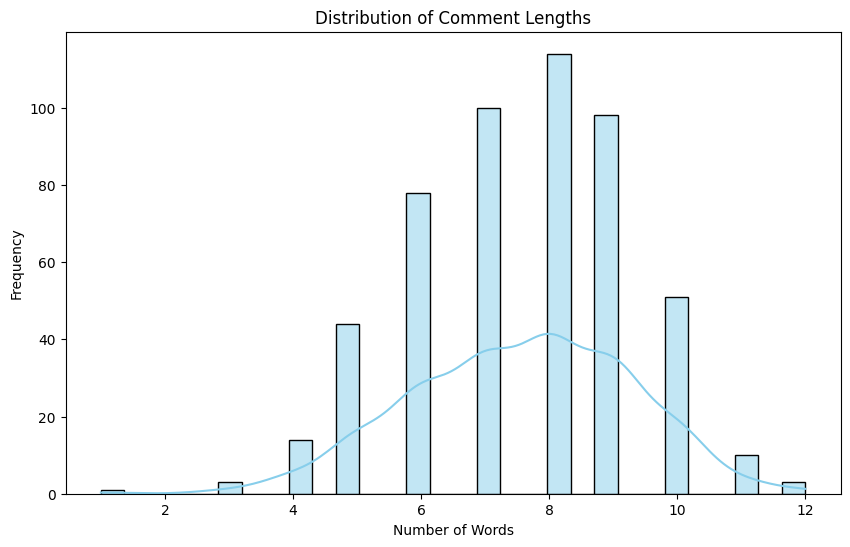

Exploratory data analysis completed.


/tmp/ipython-input-20-1034046575.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')


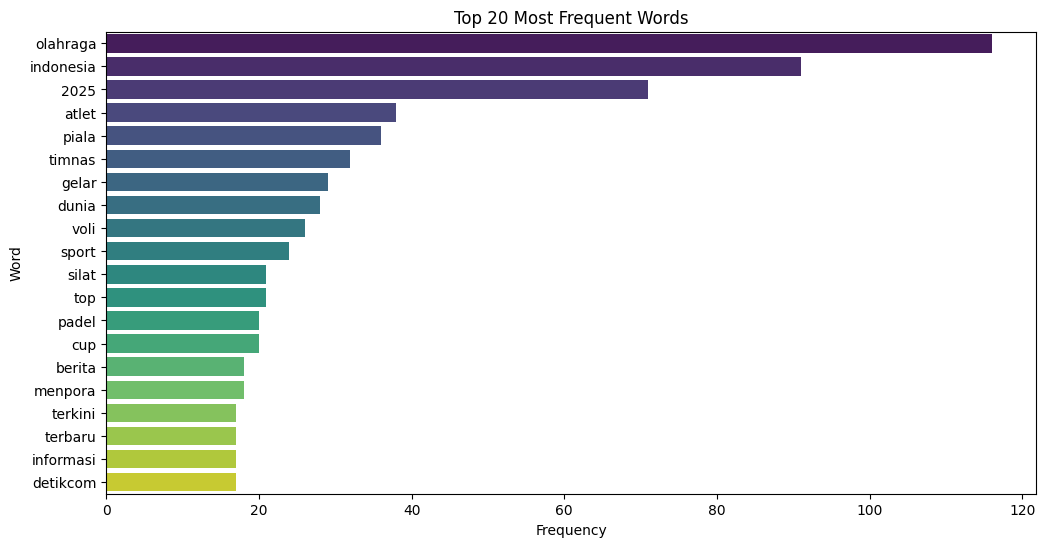

In [ ]:
# 3.2. Comment Length Distribution:
df['comment_length'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()
print("Exploratory data analysis completed.")

eda(df)


In [ ]:
from collections import Counter

# Function to count word frequency
def count_word_frequency(text_series):
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    return word_counts

# Get word frequency dictionary
word_freq = count_word_frequency(df['cleaned_text'])

# Convert to DataFrame
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

# Print all word frequencies
print("\nWord Frequency List:")
print(word_freq_df.to_string(index=False))  # Print entire frequency list


Word Frequency List:
               Word  Frequency
           olahraga        116
          indonesia         91
               2025         71
              atlet         38
              piala         36
             timnas         32
              gelar         29
              dunia         28
               voli         26
              sport         24
              silat         21
                top         21
              padel         20
                cup         20
             berita         18
            menpora         18
            terkini         17
            terbaru         17
          informasi         17
           detikcom         17
              juara         17
          kejuaraan         17
              final         17
             pencak         17
              hasil         15
               game         15
               liga         14
        bhayangkara         14
               emas         14
                sea         14
            jakar

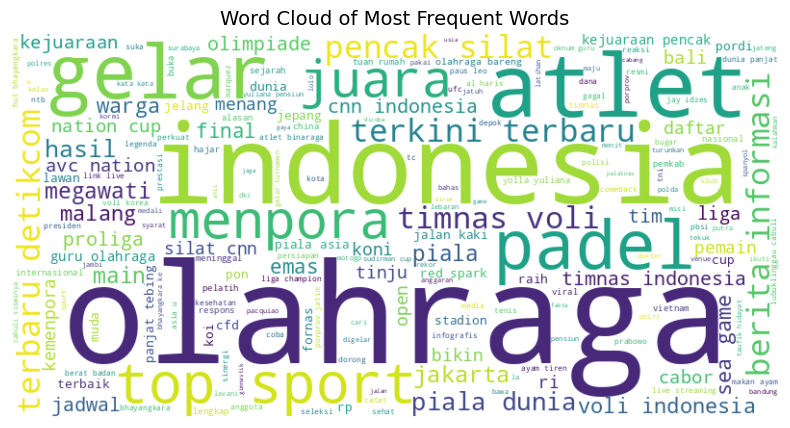

In [ ]:
# Generate Word Cloud

from wordcloud import WordCloud
def generate_wordcloud(text_series):
    text = ' '.join(text_series)
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Word Cloud of Most Frequent Words", fontsize=14)
    plt.show()

# Generate and display the word cloud
generate_wordcloud(df['cleaned_text'])

/tmp/ipython-input-24-3310986620.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_df["Frequency"], y=bigram_df["Bigram"].apply(lambda x: ' '.join(x)), palette="magma")


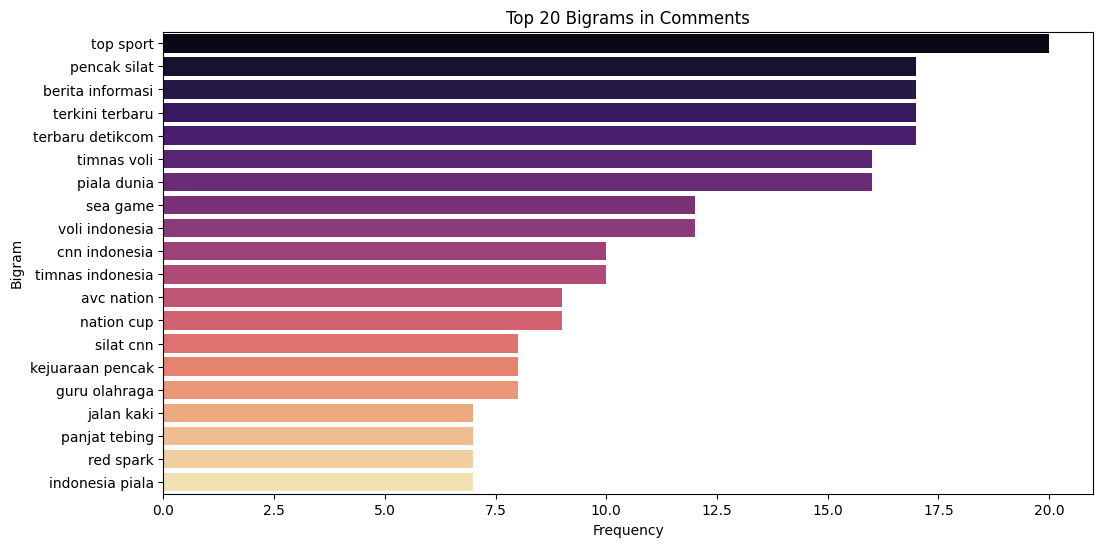

In [ ]:
# Most Frequent Word Pairs
from nltk.util import bigrams

# Generate bigrams
all_words = ' '.join(df['cleaned_text']).split()
bigrams_list = list(bigrams(all_words))

# Count most common bigrams
bigram_counts = Counter(bigrams_list)
bigram_df = pd.DataFrame(bigram_counts.most_common(20), columns=["Bigram", "Frequency"])

# Plot bigram bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=bigram_df["Frequency"], y=bigram_df["Bigram"].apply(lambda x: ' '.join(x)), palette="magma")
plt.title("Top 20 Bigrams in Comments")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

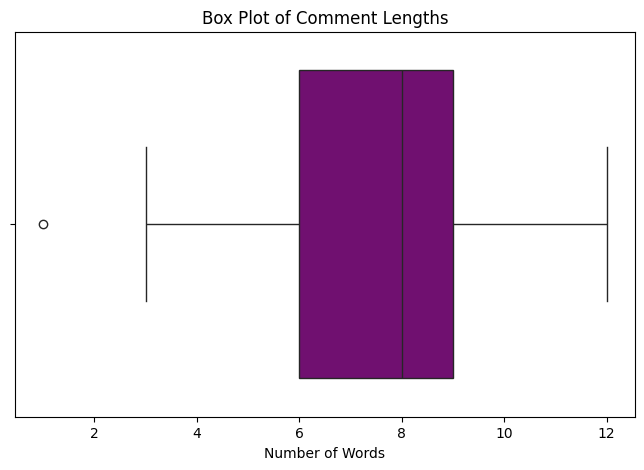

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['comment_length'], color='purple')
plt.title("Box Plot of Comment Lengths")
plt.xlabel("Number of Words")
plt.show()

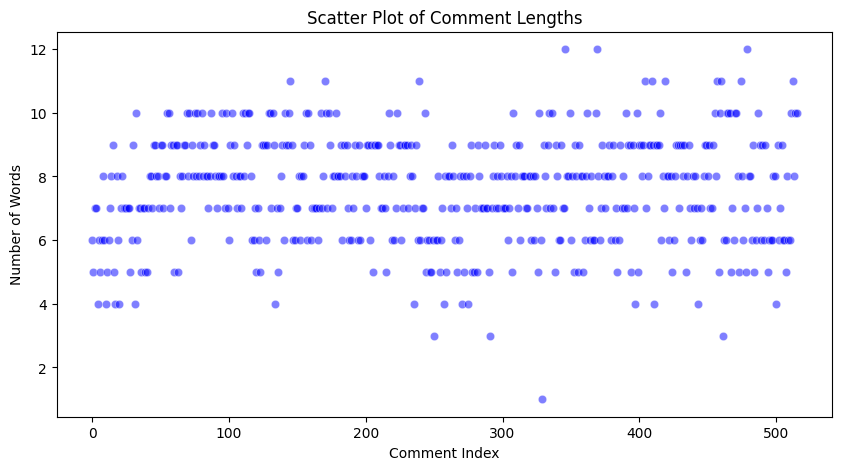

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=range(len(df)), y=df['comment_length'], alpha=0.5, color="blue")
plt.title("Scatter Plot of Comment Lengths")
plt.xlabel("Comment Index")
plt.ylabel("Number of Words")
plt.show()

/tmp/ipython-input-27-3135578455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=first_word_counts.values, y=first_word_counts.index, palette="coolwarm")


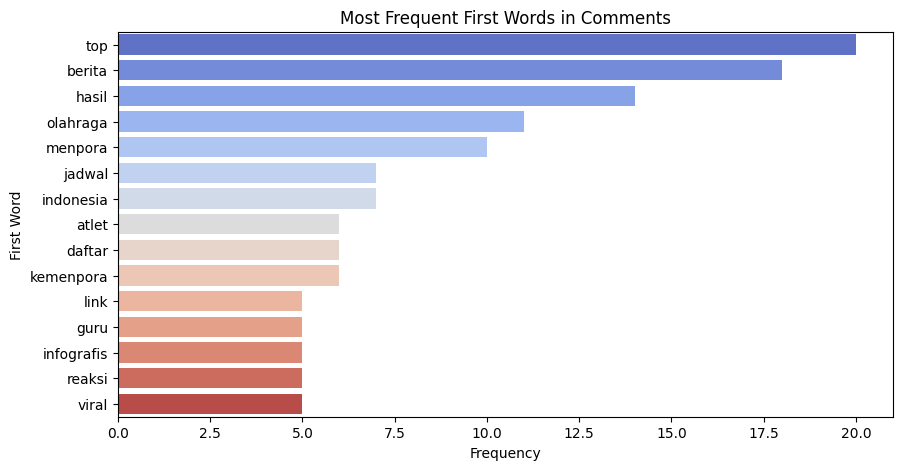

In [ ]:
first_words = df['cleaned_text'].apply(lambda x: x.split()[0] if isinstance(x, str) and x else None)
first_word_counts = first_words.value_counts().nlargest(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=first_word_counts.values, y=first_word_counts.index, palette="coolwarm")
plt.title("Most Frequent First Words in Comments")
plt.xlabel("Frequency")
plt.ylabel("First Word")
plt.show()

# **BERTopic**

In [ ]:
# Instal library utama BERTopic
!pip install bertopic

# Untuk visualisasi, instal juga paket ini
!pip install bertopic[visualization]

# Anda juga akan memerlukan sentence-transformers
!pip install sentence-transformers

# Dan pandas untuk mengelola data
!pip install pandas

In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords # Import stopwords

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer


# Step 1 - Extract embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Step 2 - Reduce dimensionality
umap_model = UMAP(n_neighbors=15, n_components=2, min_dist=0.1, metric='cosine', random_state=42)

# Step 3 - Cluster reduced embeddings
# Adjust min_cluster_size and min_samples to potentially get more topics
hdbscan_model = HDBSCAN(min_cluster_size=3, min_samples=3, metric='euclidean', cluster_selection_method='eom', prediction_data=True) # Reduced values

# Step 4 - Tokenize topics
# Get Indonesian stop words from NLTK and combine with custom stopwords
nltk_stop_words = set(stopwords.words('indonesian'))
all_stop_words = list(nltk_stop_words.union(custom_stopwords)) # Use the custom_stopwords defined earlier

vectorizer_model = CountVectorizer(stop_words=all_stop_words) # Pass the list of stop words

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with
# a `bertopic.representation` model
representation_model = KeyBERTInspired()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
  representation_model=representation_model, # Step 6 - (Optional) Fine-tune topic representations
  calculate_probabilities=True
)

In [ ]:
from bertopic import BERTopic

documents = df['cleaned_text'].tolist()
topics, probs = topic_model.fit_transform(documents)

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,118,-1_streaming_indonesia_kualifikasi_hilangkan,"[streaming, indonesia, kualifikasi, hilangkan,...",[link live streaming jepang indonesia kualifik...
1,0,32,0_marquez_palmeiras_sport_piala,"[marquez, palmeiras, sport, piala, champion, j...",[top sport jay idzes diminati aston villa palm...
2,1,22,1_indonesia_yuliana_gantikan_perunggu,"[indonesia, yuliana, gantikan, perunggu, tasik...",[alasan yolla yuliana pensiun timnas voli indo...
3,2,21,2_detikcom_informasi_terkini_terbaru,"[detikcom, informasi, terkini, terbaru, berita...",[berita informasi olahraga muda terkini terbar...
4,3,18,3_promosikan_fornas_sukseskan_2025,"[promosikan, fornas, sukseskan, 2025, kebangsa...",[kormi tuntas gelar rakernas bahas persiapan f...
5,4,14,4_sea_game_esports_gimnastik,"[sea, game, esports, gimnastik, indonesia, sel...",[gimnastik indonesia bidik medali sea game 202...
6,5,14,5_indonesia_cup_tuan_siapkah,"[indonesia, cup, tuan, siapkah, kans, langsung...",[indonesia ditawarkan tuan rumah sudirman cup ...
7,6,12,6_olahraga_guru_siswinya_aksinya,"[olahraga, guru, siswinya, aksinya, kesibukan,...",[guru olahraga lubuklinggau cabuli siswinya te...
8,7,12,7_jakarta_indonesia_bali_ajang,"[jakarta, indonesia, bali, ajang, kapolri, ola...","[taman tersebar jakarta piknik olahraga, wagub..."
9,8,11,8_bhayangkara_pertukaran_kejuaraan_olahraga,"[bhayangkara, pertukaran, kejuaraan, olahraga,...",[potret kebersamaan polisi-tni se-riau olahrag...


In [ ]:
topic_model.get_topic(0)

[('marquez', 0.5203517),
 ('palmeiras', 0.46440136),
 ('sport', 0.45670062),
 ('piala', 0.42589405),
 ('champion', 0.41938657),
 ('juara', 0.40835372),
 ('madrid', 0.40716326),
 ('fiba', 0.40306103),
 ('hajar', 0.40007564),
 ('penjas', 0.39874333)]

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_barchart()

In [ ]:
topic_model.visualize_distribution(probs[0])

In [ ]:
topic_model.visualize_hierarchy()

# **LDA**

In [ ]:
!pip install pyldavis

In [ ]:
!pip install --upgrade numpy
!pip install --upgrade gensim --no-cache-dir --force-reinstall

  Using cached numpy-2.3.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.1-cp311-cp311-manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.3.1 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.3.1 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.1 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.1 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 143.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 158.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 141.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 132.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.1
    Uninstalling numpy-2.3.1:
      Successfully uninstalled numpy-2.3.1
  Attempting uninstall: smart-open
    Found existing installation: smart_open 7.3.0.post1
    Uninstalling smart_open-7.3.0.post1:
      Su

In [ ]:
import gensim
from gensim.utils import simple_preprocess

def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=False))


In [ ]:
word_tokens = df['cleaned_text'].dropna().values.tolist()
data_tokens = list(sent_to_words(word_tokens))

len(data_tokens)

516

In [ ]:
bigram = gensim.models.Phrases(data_tokens, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_tokens], threshold=100)

In [ ]:
for index in range(len(data_tokens)):
  for token in bigram[data_tokens[index]]:
    if '_' in token:
      data_tokens[index].append(token)
  for token in trigram[data_tokens[index]]:
    if '_' in token:
      data_tokens[index].append(token)

In [ ]:
from gensim import corpora, models

# create dictionary
dictionary = corpora.Dictionary(data_tokens)

# create corpus
corpus = [dictionary.doc2bow(token) for token in data_tokens]

In [ ]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel
from numpy import array

def get_coherence_values(dictionary, corpus, tokens, num_topics):
  model_list = []
  coherence_values = []
  for i in range(1, num_topics+1):
    model = LdaModel(corpus=corpus, id2word=dictionary,
                     num_topics=i, iterations=100, random_state=2021)
    coherence_model = CoherenceModel(model=model, texts=tokens,
                                     dictionary=dictionary, coherence='c_v')
    model_list.append(model)
    coherence_values.append(coherence_model.get_coherence())

  return model_list, coherence_values

In [ ]:
num_topics = 10
model_list, coherence_values = get_coherence_values(dictionary, corpus,
                                                    data_tokens, num_topics)

In [ ]:
coherence_df = pd.DataFrame(list(zip([i+1 for i in range(num_topics)], coherence_values)),
                            columns=['num_of_topics', 'coherence_values'])
coherence_df

,num_of_topics,coherence_values
0,1,0.443379
1,2,0.417979
2,3,0.453439
3,4,0.467652
4,5,0.482168
5,6,0.471686
6,7,0.485060
7,8,0.505378
8,9,0.492803
9,10,0.499044


In [ ]:
# build LDA Model
model = LdaModel(corpus=corpus, num_topics=9, id2word=dictionary)

In [ ]:
for index, topic in model.print_topics(-1):
  print('Topic {}:\nWord: {}\n'.format(index+1, topic))

Topic 1:
Word: 0.026*"sea_game" + 0.026*"olahraga" + 0.014*"piala" + 0.011*"top_sport" + 0.011*"game" + 0.010*"indonesia" + 0.010*"panjat_tebing" + 0.009*"padel" + 0.009*"gelar" + 0.009*"timnas"

Topic 2:
Word: 0.023*"olahraga" + 0.013*"voli" + 0.013*"indonesia" + 0.011*"timnas" + 0.010*"top_sport" + 0.009*"avc_nation" + 0.008*"guru" + 0.008*"cabuli" + 0.008*"hasil" + 0.007*"kata"

Topic 3:
Word: 0.012*"olahraga" + 0.008*"menpora" + 0.008*"indonesia" + 0.006*"juara" + 0.006*"padel" + 0.006*"kemenpora" + 0.006*"liga" + 0.006*"prabowo" + 0.004*"berita_informasi" + 0.004*"terkini_terbaru"

Topic 4:
Word: 0.022*"indonesia" + 0.019*"voli" + 0.013*"atlet" + 0.012*"timnas" + 0.011*"yolla_yuliana" + 0.009*"emas" + 0.007*"dunia" + 0.007*"jalan_kaki" + 0.007*"asia" + 0.007*"juara"

Topic 5:
Word: 0.030*"indonesia" + 0.016*"piala" + 0.014*"top_sport" + 0.010*"dunia" + 0.009*"atlet" + 0.008*"fornas" + 0.006*"jalan_kaki" + 0.006*"red_spark" + 0.006*"jadwal" + 0.006*"olahraga"

Topic 6:
Word: 0.029*

In [ ]:
def format_topics_sentences(ldamodel=None, corpus=None, texts=None):
    rows = []

    for i, row_list in enumerate(ldamodel[corpus]):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: (x[1]), reverse=True)

        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                rows.append([
                    int(topic_num),
                    round(prop_topic, 4),
                    topic_keywords,
                    " ".join(texts[i])
                ])
            else:
                break

    sent_topics_df = pd.DataFrame(rows, columns=[
        'Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords', 'Text'
    ])
    return sent_topics_df

In [ ]:
df_topic_sents_keywords = format_topics_sentences(ldamodel=model,
                                                  corpus=corpus,
                                                  texts=data_tokens)

df_dominant_topic = df_topic_sents_keywords.reset_index()
df_dominant_topic.columns = ['Document_No', 'Dominant_Topic',
                             'Topic_Perc_Contrib', 'Keywords', 'Text']

In [ ]:
df_dominant_topic[:20:]

,Document_No,Dominant_Topic,Topic_Perc_Contrib,Keywords,Text
0,0,7,0.8730,"olahraga, top_sport, padel, final, guru, sport...",sains olahraga bikin awet muda umur
1,1,6,0.8518,"terkini_terbaru, berita_informasi, olahraga, i...",turunkan berat badan terbaik olahraga
2,2,0,0.8889,"sea_game, olahraga, piala, top_sport, game, in...",patut dicoba olahraga ampuh jaga kesehatan liver
3,3,8,0.8889,"olahraga, tuan_rumah, indonesia, dunia, atlet,...",anti repot opsi olahraga ringan bawa anak
4,4,3,0.5812,"indonesia, voli, atlet, timnas, yolla_yuliana,...",jalan kaki olahraga ahli jalan_kaki jalan_kaki
5,5,6,0.8518,"terkini_terbaru, berita_informasi, olahraga, i...",olahraga terbaik jaga keseimbangan usia
6,6,5,0.8518,"top_sport, sea_game, olahraga, indonesia, spor...",olahraga makan perhatikan saran ahli
7,7,1,0.8518,"olahraga, voli, indonesia, timnas, top_sport, ...",alasan rajin olahraga berat badan
8,8,6,0.8888,"terkini_terbaru, berita_informasi, olahraga, i...",viral metode olahraga efektifkah turunkan bera...
9,9,6,0.8730,"terkini_terbaru, berita_informasi, olahraga, i...",olahraga rem dorongan kompulsif masturbasi dokter


In [ ]:
import pyLDAvis.gensim

topic_data = pyLDAvis.gensim.prepare(model, corpus=corpus, dictionary=dictionary, mds='pcoa')
pyLDAvis.display(topic_data)